# RQ1: Emotional Tone (Sentiment Analysis)

**Research Question 1 - How does emotional tone differ between platforms and stances?**

This notebook scores every Reddit and YouTube comment with two complementary
lexicon/rule based methods, compares sentiment across platforms and political
stances, validates the differences with statistical tests, and exports a
sentiment-enriched dataset for the downstream modules (03 Topics, 04 Echo
Chambers, 05 Toxicity).

- **VADER** - valence-aware, social-media tuned compound score in [-1, 1].
- **TextBlob** - polarity in [-1, 1] and subjectivity in [0, 1].

**Stance labels:** `P` = Pro-Palestine, `I` = Pro-Israel, `N` = Neutral.

## 1. Setup and Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy import stats
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings("ignore")
tqdm.pandas()

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

STANCE_ORDER = ["P", "I", "N"]
STANCE_NAMES = {"P": "Pro-Palestine", "I": "Pro-Israel", "N": "Neutral"}
STANCE_COLORS = {"P": "#2ecc71", "I": "#3498db", "N": "#95a5a6"}
SENT_COLORS = {"positive": "#2ecc71", "neutral": "#95a5a6", "negative": "#e74c3c"}


def find_repo_root():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "data" / "reddit_labeled.csv").exists():
            return candidate
    return here


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data"
OUTPUT_DIR = REPO_ROOT / "02_emotional_tone_analysis" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Libraries imported successfully")
print(f"Data dir  : {DATA_DIR}")
print(f"Output dir: {OUTPUT_DIR}")

Libraries imported successfully
Data dir  : C:\Users\nitro 5\Desktop\Projects\israel_hamas_discourse_analysis\data
Output dir: C:\Users\nitro 5\Desktop\Projects\israel_hamas_discourse_analysis\02_emotional_tone_analysis\outputs


c:\Users\nitro 5\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Labeled Data

In [2]:
print("Loading labeled data...")
reddit_df = pd.read_csv(DATA_DIR / "reddit_labeled.csv")
youtube_df = pd.read_csv(DATA_DIR / "youtube_labeled.csv")

# Keep only the three valid stance labels
reddit_df = reddit_df[reddit_df["Label"].isin(STANCE_ORDER)].copy()
youtube_df = youtube_df[youtube_df["Label"].isin(STANCE_ORDER)].copy()

# Parse timestamps for the temporal section
reddit_df["created_time"] = pd.to_datetime(reddit_df["created_time"], errors="coerce")
youtube_df["created_time"] = pd.to_datetime(youtube_df["created_time"], errors="coerce")

# Text columns differ per platform
REDDIT_TEXT, YOUTUBE_TEXT = "self_text", "text"

print(f"Reddit : {len(reddit_df):,} comments")
print(f"YouTube: {len(youtube_df):,} comments")

Loading labeled data...
Reddit : 1,110,153 comments
YouTube: 378,267 comments


## 3. Sentiment Scoring Functions

VADER returns a `compound` score plus positive/neutral/negative proportions.
We label a comment positive if compound >= 0.05, negative if <= -0.05, else
neutral (the standard VADER thresholds). TextBlob adds polarity and a
subjectivity score.

In [3]:
vader = SentimentIntensityAnalyzer()


def vader_scores(text):
    if not isinstance(text, str) or text == "":
        return (0.0, 0.0, 0.0, 0.0, "neutral")
    s = vader.polarity_scores(text)
    if s["compound"] >= 0.05:
        label = "positive"
    elif s["compound"] <= -0.05:
        label = "negative"
    else:
        label = "neutral"
    return (s["compound"], s["pos"], s["neu"], s["neg"], label)


def textblob_scores(text):
    if not isinstance(text, str) or text == "":
        return (0.0, 0.0, "neutral")
    blob = TextBlob(text)
    pol = blob.sentiment.polarity
    subj = blob.sentiment.subjectivity
    if pol > 0.1:
        label = "positive"
    elif pol < -0.1:
        label = "negative"
    else:
        label = "neutral"
    return (pol, subj, label)


VADER_COLS = ["vader_compound", "vader_pos", "vader_neu", "vader_neg", "vader_label"]
TB_COLS = ["textblob_polarity", "textblob_subjectivity", "textblob_label"]
print("Sentiment scoring functions defined")

Sentiment scoring functions defined


## 4. Apply Sentiment Scoring

Scoring runs over the full dataset (~1.5M comments). A single pass per method is
used (progress bars shown); expect a few minutes total.

In [5]:
def score_frame(df, text_col):
    texts = df[text_col].fillna("").astype(str)
    vad = pd.DataFrame(
        [vader_scores(text) for text in tqdm(texts, total=len(texts), desc="VADER scoring")],
        columns=VADER_COLS,
        index=df.index,
    )
    tb = pd.DataFrame(
        [textblob_scores(text) for text in tqdm(texts, total=len(texts), desc="TextBlob scoring")],
        columns=TB_COLS,
        index=df.index,
    )
    return pd.concat([df, vad, tb], axis=1)


print("Scoring Reddit...")
reddit_df = score_frame(reddit_df, REDDIT_TEXT)
print("Scoring YouTube...")
youtube_df = score_frame(youtube_df, YOUTUBE_TEXT)

print("\nReddit VADER label distribution:")
print(reddit_df["vader_label"].value_counts())
print("\nYouTube VADER label distribution:")
print(youtube_df["vader_label"].value_counts())

Scoring Reddit...


TextBlob scoring: 100%|██████████| 1110153/1110153 [07:30<00:00, 2462.39it/s]


Scoring YouTube...


TextBlob scoring: 100%|██████████| 378267/378267 [01:29<00:00, 4218.63it/s]



Reddit VADER label distribution:
vader_label
negative    567841
positive    358138
neutral     184174
Name: count, dtype: int64

YouTube VADER label distribution:
vader_label
positive    155597
negative    118452
neutral     104218
Name: count, dtype: int64


## 5. Sentiment Distribution Visualizations

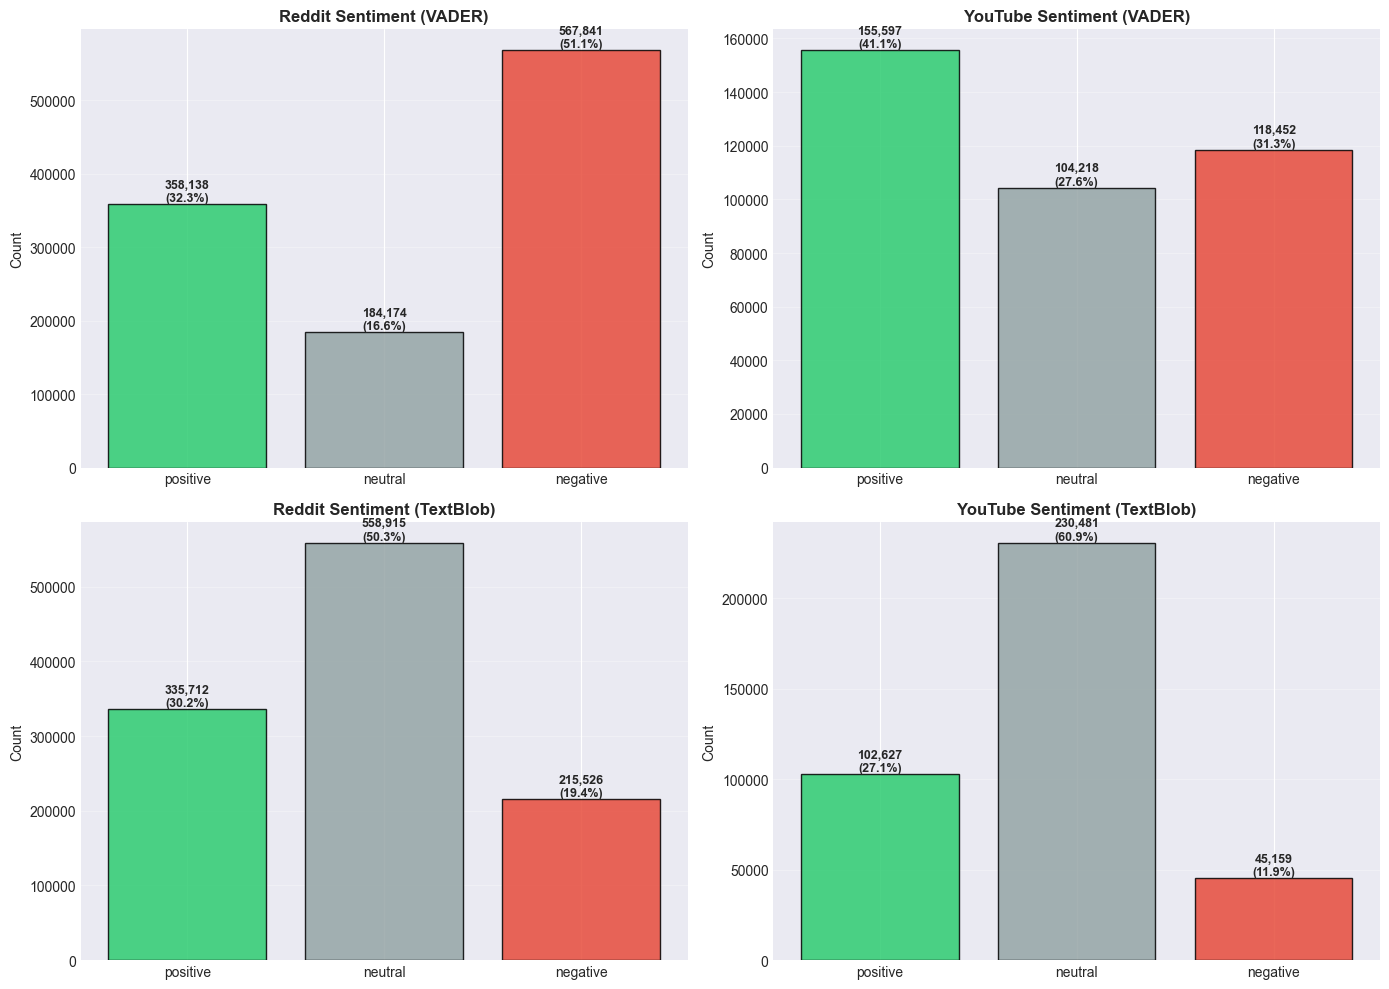

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
order = ["positive", "neutral", "negative"]

panels = [
    (axes[0, 0], reddit_df, "vader_label", "Reddit Sentiment (VADER)"),
    (axes[0, 1], youtube_df, "vader_label", "YouTube Sentiment (VADER)"),
    (axes[1, 0], reddit_df, "textblob_label", "Reddit Sentiment (TextBlob)"),
    (axes[1, 1], youtube_df, "textblob_label", "YouTube Sentiment (TextBlob)"),
]
for ax, df, col, title in panels:
    counts = df[col].value_counts().reindex(order).fillna(0)
    bars = ax.bar(order, counts.values, color=[SENT_COLORS[o] for o in order],
                  alpha=0.85, edgecolor="black")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.3)
    total = counts.sum()
    for b, v in zip(bars, counts.values):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,.0f}\n({v/total*100:.1f}%)",
                ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Sentiment by Stance

Mean VADER compound score and sentiment-label mix for each stance, per platform.

In [7]:
def stance_sentiment_table(df, name):
    print("=" * 70)
    print(f"{name}: VADER sentiment statistics by stance")
    print("=" * 70)
    tbl = df.groupby("Label").agg(
        n=("vader_compound", "size"),
        compound_mean=("vader_compound", "mean"),
        compound_median=("vader_compound", "median"),
        compound_std=("vader_compound", "std"),
        pos=("vader_pos", "mean"),
        neg=("vader_neg", "mean"),
    ).reindex(STANCE_ORDER).round(3)
    tbl.index = [STANCE_NAMES[s] for s in tbl.index]
    print(tbl)
    return tbl


_ = stance_sentiment_table(reddit_df, "REDDIT")
_ = stance_sentiment_table(youtube_df, "YOUTUBE")

REDDIT: VADER sentiment statistics by stance
                    n  compound_mean  compound_median  compound_std    pos  \
Pro-Palestine  494608         -0.214           -0.273         0.569  0.100   
Pro-Israel     370616         -0.217           -0.296         0.598  0.103   
Neutral        244929          0.030            0.000         0.504  0.126   

                 neg  
Pro-Palestine  0.142  
Pro-Israel     0.142  
Neutral        0.090  
YOUTUBE: VADER sentiment statistics by stance
                    n  compound_mean  compound_median  compound_std    pos  \
Pro-Palestine  212217          0.038              0.0         0.533  0.163   
Pro-Israel     131357          0.107              0.0         0.537  0.183   
Neutral         34693          0.105              0.0         0.509  0.184   

                 neg  
Pro-Palestine  0.123  
Pro-Israel     0.104  
Neutral        0.113  


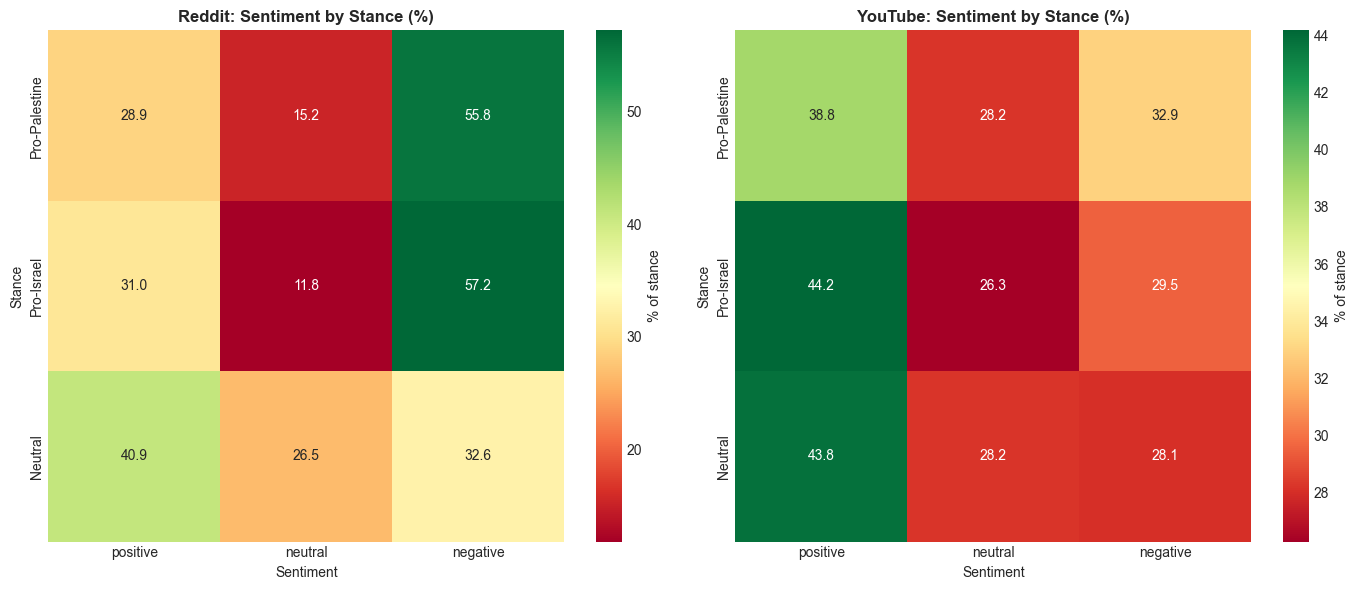

In [8]:
# Heatmaps: sentiment mix (%) by stance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, df, title in [(axes[0], reddit_df, "Reddit"), (axes[1], youtube_df, "YouTube")]:
    ct = pd.crosstab(df["Label"], df["vader_label"], normalize="index") * 100
    ct = ct.reindex(index=STANCE_ORDER, columns=["positive", "neutral", "negative"])
    ct.index = [STANCE_NAMES[s] for s in ct.index]
    sns.heatmap(ct, annot=True, fmt=".1f", cmap="RdYlGn", ax=ax,
                cbar_kws={"label": "% of stance"})
    ax.set_title(f"{title}: Sentiment by Stance (%)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Sentiment"); ax.set_ylabel("Stance")
plt.tight_layout()
plt.show()

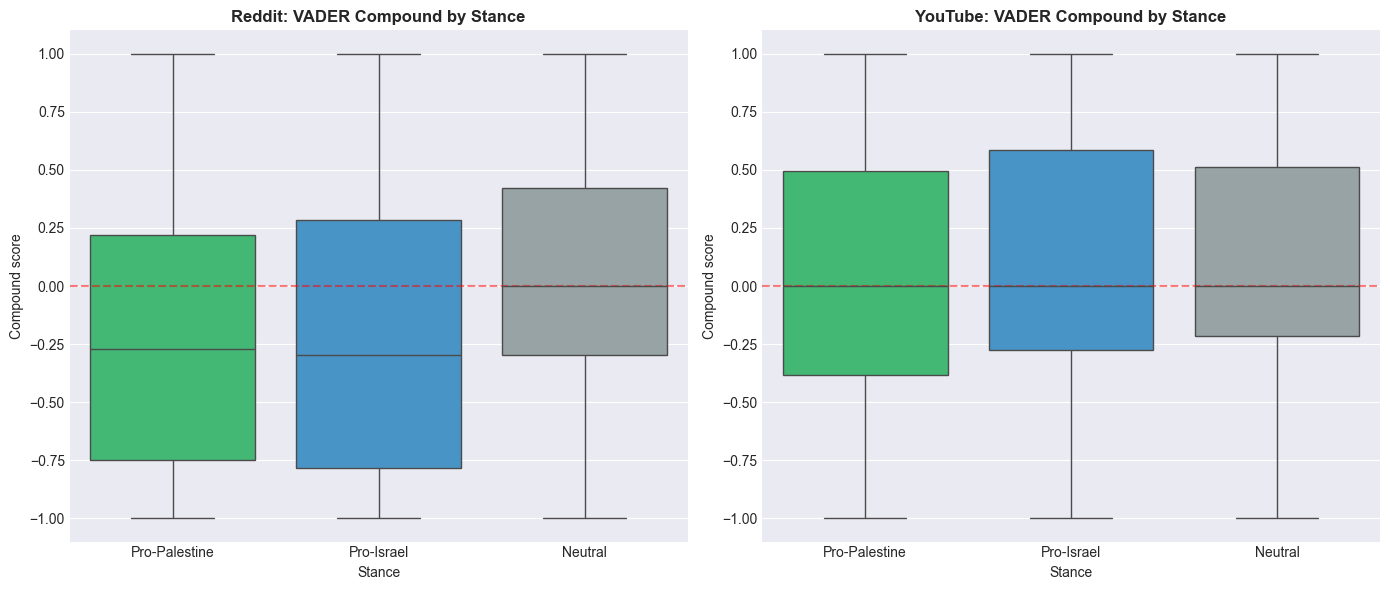

In [9]:
# Box plots: compound score by stance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, df, title in [(axes[0], reddit_df, "Reddit"), (axes[1], youtube_df, "YouTube")]:
    sns.boxplot(data=df, x="Label", y="vader_compound", order=STANCE_ORDER,
                hue="Label", hue_order=STANCE_ORDER, palette=STANCE_COLORS,
                legend=False, showfliers=False, ax=ax)
    ax.set_xticklabels([STANCE_NAMES[s] for s in STANCE_ORDER])
    ax.axhline(0, color="red", linestyle="--", alpha=0.5)
    ax.set_title(f"{title}: VADER Compound by Stance", fontsize=12, fontweight="bold")
    ax.set_xlabel("Stance"); ax.set_ylabel("Compound score")
plt.tight_layout()
plt.show()

## 7. Polarity vs Subjectivity

TextBlob polarity against subjectivity. Plotted on a stratified sample per stance
(full data would be ~1.5M overlapping points).

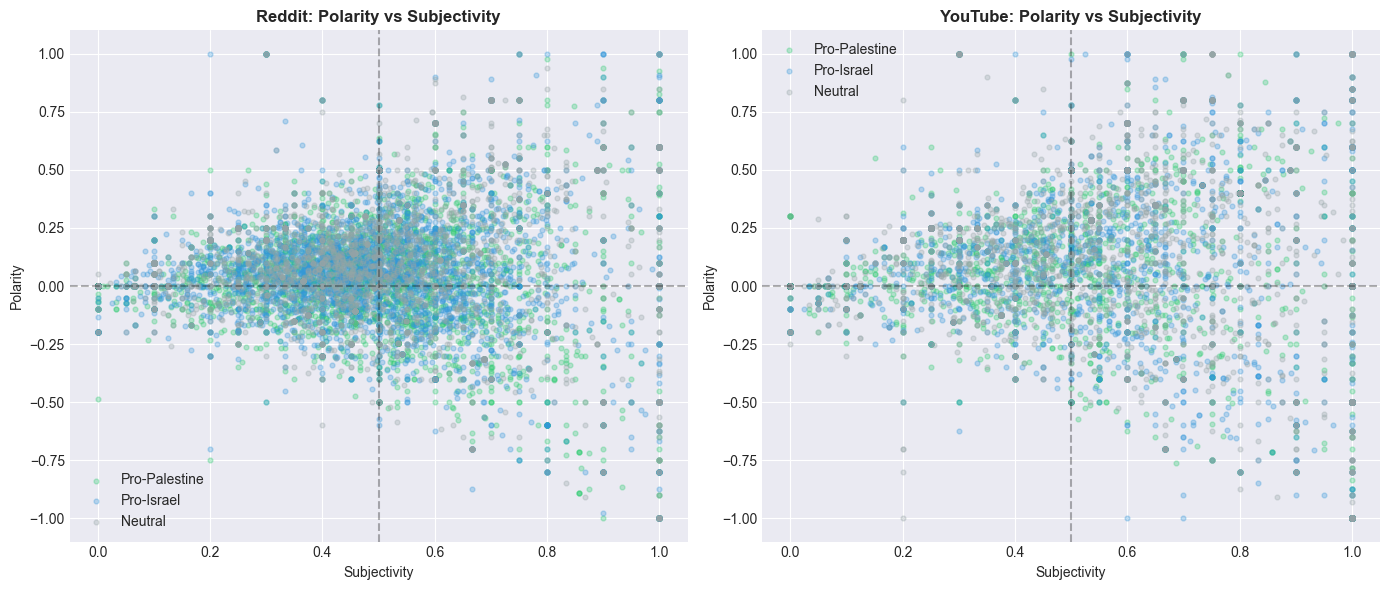

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
SAMPLE_PER_STANCE = 4000
for ax, df, title in [(axes[0], reddit_df, "Reddit"), (axes[1], youtube_df, "YouTube")]:
    for stance in STANCE_ORDER:
        sub = df[df["Label"] == stance]
        if len(sub) > SAMPLE_PER_STANCE:
            sub = sub.sample(SAMPLE_PER_STANCE, random_state=42)
        ax.scatter(sub["textblob_subjectivity"], sub["textblob_polarity"],
                   alpha=0.3, s=12, c=STANCE_COLORS[stance], label=STANCE_NAMES[stance])
    ax.axhline(0, color="black", linestyle="--", alpha=0.3)
    ax.axvline(0.5, color="black", linestyle="--", alpha=0.3)
    ax.set_title(f"{title}: Polarity vs Subjectivity", fontsize=12, fontweight="bold")
    ax.set_xlabel("Subjectivity"); ax.set_ylabel("Polarity")
    ax.legend()
plt.tight_layout()
plt.show()

## 8. Platform Comparison

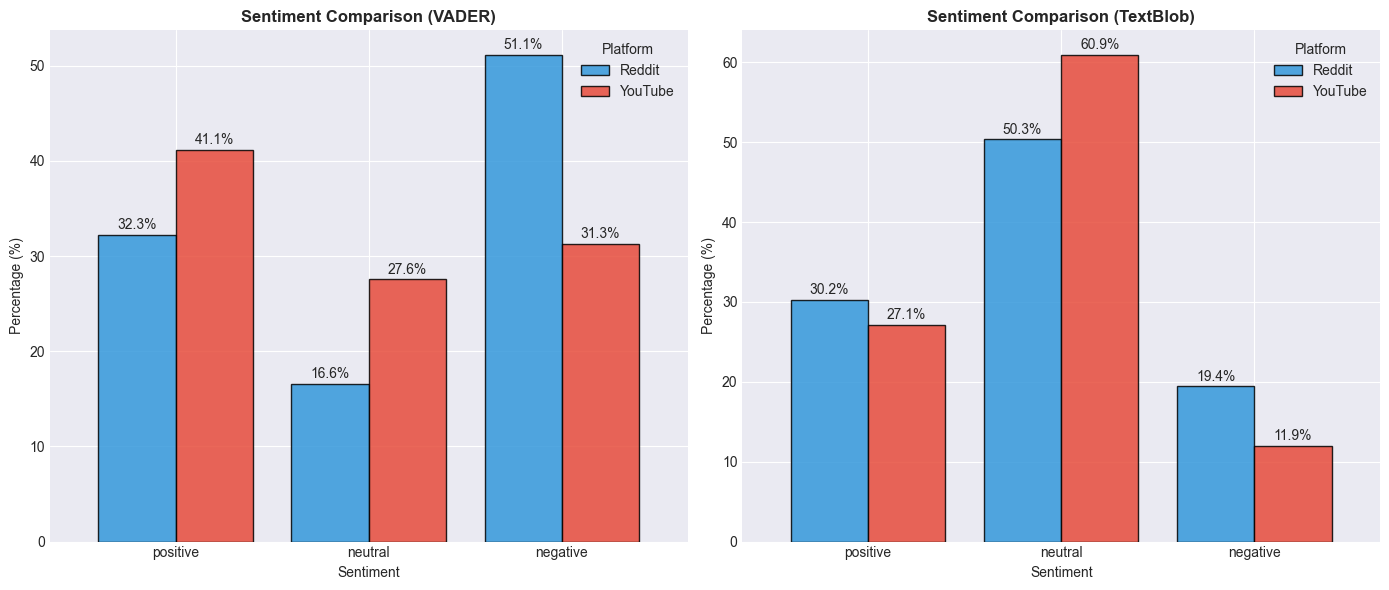

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
order = ["positive", "neutral", "negative"]
for ax, col, title in [(axes[0], "vader_label", "VADER"),
                       (axes[1], "textblob_label", "TextBlob")]:
    comp = pd.DataFrame({
        "Reddit": reddit_df[col].value_counts(normalize=True) * 100,
        "YouTube": youtube_df[col].value_counts(normalize=True) * 100,
    }).reindex(order).fillna(0)
    comp.plot(kind="bar", ax=ax, color=["#3498db", "#e74c3c"], alpha=0.85,
              edgecolor="black", width=0.8)
    ax.set_title(f"Sentiment Comparison ({title})", fontsize=12, fontweight="bold")
    ax.set_xlabel("Sentiment"); ax.set_ylabel("Percentage (%)")
    ax.legend(title="Platform")
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=2)
plt.tight_layout()
plt.show()

## 9. Statistical Significance Tests

We validate the visual differences with formal tests:

- **Chi-square** - is the sentiment-label mix independent of stance? (per platform)
- **Kruskal-Wallis** - do compound-score distributions differ across the three stances?
- **Mann-Whitney U** - does the compound-score distribution differ between platforms?

Cramer's V is reported as an effect size for the chi-square tests because, with
~1.5M observations, even trivial differences reach significance.

In [12]:
def cramers_v(confusion):
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.to_numpy().sum()
    r, k = confusion.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))


print("CHI-SQUARE: stance vs sentiment label")
for name, df in [("Reddit", reddit_df), ("YouTube", youtube_df)]:
    ct = pd.crosstab(df["Label"], df["vader_label"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"  {name}: chi2={chi2:,.1f}, dof={dof}, p={p:.3e}, "
          f"Cramer's V={cramers_v(ct):.3f}")

print("\nKRUSKAL-WALLIS: VADER compound across stances")
for name, df in [("Reddit", reddit_df), ("YouTube", youtube_df)]:
    groups = [df[df["Label"] == s]["vader_compound"].dropna() for s in STANCE_ORDER]
    h, p = stats.kruskal(*groups)
    print(f"  {name}: H={h:,.1f}, p={p:.3e}")

print("\nMANN-WHITNEY U: Reddit vs YouTube compound")
u, p = stats.mannwhitneyu(reddit_df["vader_compound"].dropna(),
                          youtube_df["vader_compound"].dropna(),
                          alternative="two-sided")
print(f"  U={u:,.0f}, p={p:.3e}")
print(f"  Reddit mean compound = {reddit_df['vader_compound'].mean():.4f}")
print(f"  YouTube mean compound = {youtube_df['vader_compound'].mean():.4f}")

CHI-SQUARE: stance vs sentiment label
  Reddit: chi2=49,062.5, dof=4, p=0.000e+00, Cramer's V=0.149
  YouTube: chi2=1,175.3, dof=4, p=3.598e-253, Cramer's V=0.039

KRUSKAL-WALLIS: VADER compound across stances
  Reddit: H=37,032.1, p=0.000e+00
  YouTube: H=1,442.3, p=0.000e+00

MANN-WHITNEY U: Reddit vs YouTube compound
  U=161,516,087,412, p=0.000e+00
  Reddit mean compound = -0.1612
  YouTube mean compound = 0.0680


## 9b. Effect Sizes

With ~1.5M observations almost any difference is "significant", so we report
standardized **effect sizes** alongside the p-values: **rank-biserial correlation**
for the Mann-Whitney platform contrast and **epsilon-squared (epsilon^2)** for the
Kruskal-Wallis stance comparison.

In [13]:
def rank_biserial(u, n1, n2):
    """Rank-biserial correlation from a Mann-Whitney U (sign = direction, |r| = size)."""
    return 1 - (2.0 * u) / (n1 * n2)


def epsilon_squared(h, n):
    """Epsilon-squared effect size for Kruskal-Wallis H (0..1)."""
    return h / (n - 1)


a = reddit_df["vader_compound"].dropna()
b = youtube_df["vader_compound"].dropna()
u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
print(f"Platform (VADER compound): Mann-Whitney U={u:,.0f}, p={p:.2e}, "
      f"rank-biserial r={rank_biserial(u, len(a), len(b)):+.3f}")

for name, df in [("Reddit", reddit_df), ("YouTube", youtube_df)]:
    groups = [df[df["Label"] == s]["vader_compound"].dropna() for s in STANCE_ORDER]
    h, p = stats.kruskal(*groups)
    n = sum(len(g) for g in groups)
    print(f"{name} stance (VADER compound): Kruskal H={h:,.1f}, p={p:.2e}, "
          f"epsilon^2={epsilon_squared(h, n):.4f}")

Platform (VADER compound): Mann-Whitney U=161,516,087,412, p=0.00e+00, rank-biserial r=+0.231
Reddit stance (VADER compound): Kruskal H=37,032.1, p=0.00e+00, epsilon^2=0.0334
YouTube stance (VADER compound): Kruskal H=1,442.3, p=0.00e+00, epsilon^2=0.0038


## 9c. Transformer Sentiment & Method Agreement

VADER and TextBlob are lexicon/rule methods. We add a **transformer** model
(`cardiffnlp/twitter-roberta-base-sentiment-latest`) and measure how much the three
methods agree using **Cohen's kappa**. The transformer runs on a stratified sample
per platform (CPU-only inference, so sampled; raise `TRANSFORMER_SAMPLE` on a GPU).
The model is downloaded once from Hugging Face on first run.

In [14]:
from transformers import pipeline
from sklearn.metrics import cohen_kappa_score

TRANSFORMER_SAMPLE = 6000  # per platform


def _strat(df, n):
    return df if len(df) <= n else df.groupby("Label", group_keys=False).sample(
        frac=n / len(df), random_state=42)


_clf = pipeline("sentiment-analysis",
                model="cardiffnlp/twitter-roberta-base-sentiment-latest",
                truncation=True, max_length=128)
_MAP = {"negative": "negative", "neutral": "neutral", "positive": "positive",
        "label_0": "negative", "label_1": "neutral", "label_2": "positive"}


def transformer_labels(texts, batch=64):
    out = []
    for i in range(0, len(texts), batch):
        chunk = [t[:500] if t else "" for t in texts[i:i + batch]]
        out.extend(_MAP.get(r["label"].lower(), r["label"].lower()) for r in _clf(chunk))
    return out


for name, df, tcol in [("Reddit", reddit_df, REDDIT_TEXT), ("YouTube", youtube_df, YOUTUBE_TEXT)]:
    s = _strat(df, TRANSFORMER_SAMPLE).copy()
    s["roberta_label"] = transformer_labels(s[tcol].fillna("").astype(str).tolist())
    print(f"\n{name} (n={len(s):,}) transformer label mix: "
          f"{s['roberta_label'].value_counts().to_dict()}")
    print(f"  Cohen's kappa  VADER-RoBERTa={cohen_kappa_score(s['vader_label'], s['roberta_label']):.3f}"
          f" | TextBlob-RoBERTa={cohen_kappa_score(s['textblob_label'], s['roberta_label']):.3f}"
          f" | VADER-TextBlob={cohen_kappa_score(s['vader_label'], s['textblob_label']):.3f}")

Loading weights: 100%|██████████| 201/201 [00:01<00:00, 195.93it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Reddit (n=6,000) transformer label mix: {'negative': 4071, 'neutral': 1436, 'positive': 493}
  Cohen's kappa  VADER-RoBERTa=0.263 | TextBlob-RoBERTa=0.090 | VADER-TextBlob=0.233

YouTube (n=6,000) transformer label mix: {'negative': 2692, 'neutral': 1927, 'positive': 1381}
  Cohen's kappa  VADER-RoBERTa=0.414 | TextBlob-RoBERTa=0.176 | VADER-TextBlob=0.289


## 10. Temporal Sentiment Trends

Reddit is aggregated by **comment month** (`created_time`); YouTube by **video
publish month** (`video_date`). YouTube's `created_time` is the scrape/fetch date
(it runs into 2025-2026), so `video_date` is the correct temporal anchor.

In [ ]:
# Reddit -> comment date; YouTube -> video_date (its created_time is the unreliable
# scrape date, not the comment time).
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Monthly Mean Sentiment (VADER Compound)", fontsize=14, fontweight="bold")
panels = [("Reddit", reddit_df, "created_time", "comment month", "#3498db"),
          ("YouTube", youtube_df, "video_date", "video publish month", "#e74c3c")]
for ax, (title, df, tcol, tlabel, color) in zip(axes, panels):
    period = pd.to_datetime(df[tcol], errors="coerce").dt.to_period("M")
    ts = df.assign(_period=period).dropna(subset=["_period"]).groupby("_period")["vader_compound"].mean()
    ts.index = ts.index.astype(str)
    ax.plot(ts.index, ts.values, marker="o", color=color, linewidth=2)
    ax.axhline(0, color="k", linestyle="--", alpha=0.3)
    ax.set_title(f"{title} (by {tlabel})", fontsize=12, fontweight="bold")
    ax.set_ylabel("Mean compound")
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 11. Export Sentiment-Enriched Data

Saved to `02_emotional_tone_analysis/outputs/`. Modules 03-05 load these files
(and fall back to recomputing VADER from `data/` if they are absent).

In [16]:
reddit_out = OUTPUT_DIR / "reddit_with_sentiment.csv"
youtube_out = OUTPUT_DIR / "youtube_with_sentiment.csv"

reddit_df.to_csv(reddit_out, index=False, encoding="utf-8")
youtube_df.to_csv(youtube_out, index=False, encoding="utf-8")

print(f"Exported: {reddit_out}  ({reddit_df.shape[0]:,} x {reddit_df.shape[1]})")
print(f"Exported: {youtube_out} ({youtube_df.shape[0]:,} x {youtube_df.shape[1]})")
print("\nNew sentiment columns:", VADER_COLS + TB_COLS)

Exported: C:\Users\nitro 5\Desktop\Projects\israel_hamas_discourse_analysis\02_emotional_tone_analysis\outputs\reddit_with_sentiment.csv  (1,110,153 x 26)
Exported: C:\Users\nitro 5\Desktop\Projects\israel_hamas_discourse_analysis\02_emotional_tone_analysis\outputs\youtube_with_sentiment.csv (378,267 x 18)

New sentiment columns: ['vader_compound', 'vader_pos', 'vader_neu', 'vader_neg', 'vader_label', 'textblob_polarity', 'textblob_subjectivity', 'textblob_label']


## Summary - RQ1 Findings

- **Method agreement** - VADER and TextBlob are compared side by side; VADER
  (social-media tuned) is the primary score used downstream.
- **Platform contrast** - the platform comparison and Mann-Whitney test quantify
  how Reddit and YouTube differ in overall emotional tone.
- **Stance effect** - the by-stance tables, heatmaps and Kruskal-Wallis tests show
  how Pro-Palestine, Pro-Israel and Neutral comments differ in sentiment within
  each platform, with chi-square + Cramer's V giving effect sizes.
- **Temporal** - monthly mean sentiment over the study window (Reddit by comment
  date; YouTube by video publish date, since YouTube `created_time` is an
  unreliable scrape date).

The sentiment-enriched datasets are exported for the Topics (03), Echo Chambers
(04) and Toxicity (05) modules.